In [49]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Assuming the uploaded file is a CSV, you can read it into a pandas DataFrame
  # Replace 'your_file_name.csv' with the actual name of your uploaded file
  # For this example, we'll use the first uploaded file name
  try:
    df = pd.read_csv(fn)
    print(f"Successfully loaded '{fn}' into a pandas DataFrame.")
    display(df.head())
  except Exception as e:
    print(f"Error reading '{fn}' as CSV: {e}")

Saving AB_NYC_2019.csv to AB_NYC_2019 (1).csv
User uploaded file "AB_NYC_2019 (1).csv" with length 7077973 bytes
Successfully loaded 'AB_NYC_2019 (1).csv' into a pandas DataFrame.


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [50]:
!pip install datascience

from datascience import *
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [51]:
!pip install datascience

In [52]:
from datascience import *
import numpy as np
airbnb = Table().read_table("AB_NYC_2019.csv")
airbnb.show(5)

id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.6475,-73.9724,Private room,149,1,9,2018-10-19,0.21,6,365
2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.7536,-73.9838,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.809,-73.9419,Private room,150,3,0,nan,nan,1,365
3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.6851,-73.9598,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.7985,-73.944,Entire home/apt,80,10,9,2018-11-19,0.1,1,0


In [53]:
airbnb= airbnb.where("price", are.above(0)).where("price", are.below(2000))

In [54]:
airbnb_by_loc= airbnb.select("name", "neighbourhood_group","neighbourhood","price","number_of_reviews","last_review")
airbnb_by_loc.show(10)

name,neighbourhood_group,neighbourhood,price,number_of_reviews,last_review
Clean & quiet apt home by the park,Brooklyn,Kensington,149,9,2018-10-19
Skylit Midtown Castle,Manhattan,Midtown,225,45,2019-05-21
THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Harlem,150,0,nan
Cozy Entire Floor of Brownstone,Brooklyn,Clinton Hill,89,270,2019-07-05
Entire Apt: Spacious Studio/Loft by central park,Manhattan,East Harlem,80,9,2018-11-19
Large Cozy 1 BR Apartment In Midtown East,Manhattan,Murray Hill,200,74,2019-06-22
BlissArtsSpace!,Brooklyn,Bedford-Stuyvesant,60,49,2017-10-05
Large Furnished Room Near B'way,Manhattan,Hell's Kitchen,79,430,2019-06-24
Cozy Clean Guest Room - Family Apt,Manhattan,Upper West Side,79,118,2017-07-21
Cute & Cozy Lower East Side 1 bdrm,Manhattan,Chinatown,150,160,2019-06-09


In [55]:
airbnb_by_loc = airbnb_by_loc.sort("price", descending=True)

In [56]:
avg_price_by_borough = airbnb_by_loc.group("neighbourhood_group", np.mean)
avg_price_by_borough.show()

neighbourhood_group,name mean,neighbourhood mean,price mean,number_of_reviews mean,last_review mean
Bronx,,,85.3618,26.0018,
Brooklyn,,,119.722,24.2241,
Manhattan,,,184.189,21.0438,
Queens,,,96.2581,27.7239,
Staten Island,,,101.68,31.0242,


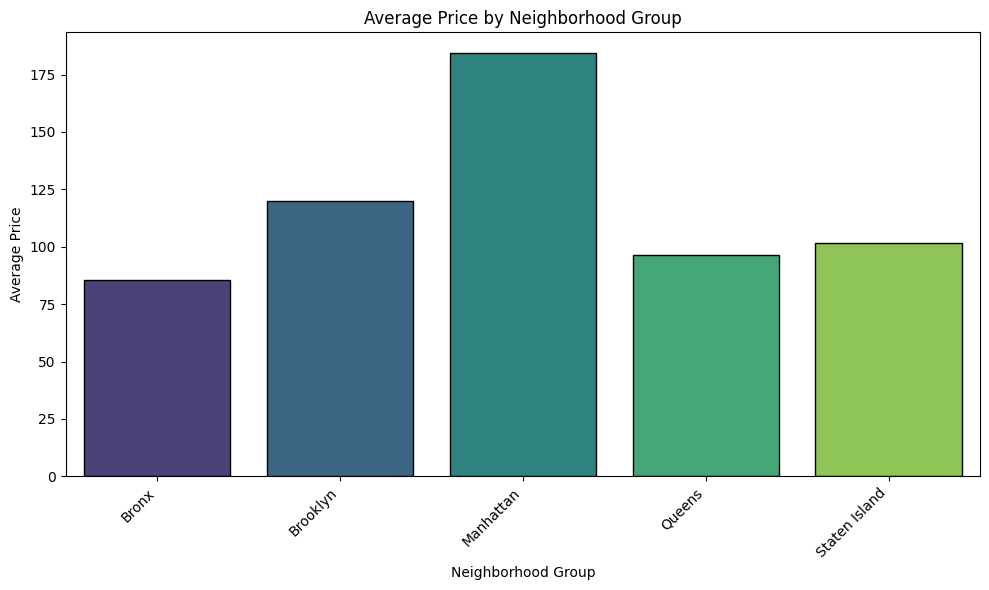

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the datascience Table to a pandas DataFrame for easier plotting with seaborn
avg_price_by_borough_df = avg_price_by_borough.to_df()

plt.figure(figsize=(10, 6))
sns.barplot(x='neighbourhood_group', y='price mean', data=avg_price_by_borough_df, palette='viridis', hue='neighbourhood_group', legend=False)
plt.title('Average Price by Neighborhood Group')
plt.xlabel('Neighborhood Group')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This bar chart shows the average Airbnb price across NYC boroughs.Manhattan has the highest average price, significantly above the other boroughs. This is likely due to its central location, high demand, and concentration of tourist attractions.This suggests that Airbnb pricing reflects broader economic inequality across NYC neighborhoods.